# **# TRANSFER LEARNING**

## **¿? CONCLUSIONES**
---
*   No importa la ubicación del objeto dentro de la imagen ➜ GlobarAveragePooling2D
*   Shuffle NO necesario (en este Dataset Cifar10)
*   Son más de 2 clases ➜ Activacion Softmax
*   Dataset Cats & Dogs ya estaba separado en Test/Train (Muy Fácil)
*   Dataset Cats & Dogs solo 6,000 imágenes, aquí 60,000 ordenadores básicos tienen problemas con la Memoria RAM, incluso con Google Colab; durante "redimensionado 32x32 ➜ 128x128". En nuestro caso hemos tenido que hacer una optimización del código para consumir lo menos posible de RAM
*   ImagiNet (Modelos: ResNet/VGG) han sido preentrenados con imagenes 224x224
*   MobileNetV2 es flexible, para tamaños comunes como 128x128, 160x160, 192x192 o 224x224 pixeles (ResNet o Inception NO lo son)




## 📁 DRIVE - CONECTAR

---

In [ ]:
# ===========================
# CONECTAR CON CARPETA DRIVE
# ===========================

import os

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/PROJECTS_DSML/CIFAR10_CNN_&_Transfer_Learning')

print("¡Trabajando desde:", os.getcwd())
print("Archivos disponibles:", os.listdir())

Mounted at /content/drive
¡Trabajando desde: /content/drive/MyDrive/PROJECTS_DSML/CIFAR10_CNN_&_Transfer_Learning
Archivos disponibles: ['cifar-10-batches-py', 'Cifar10_Transfer_Learning (Final).ipynb']


## 📚 LIBRERÍAS

---

In [ ]:
# ===============================================
# IMPORTACIONES Y CONFIGURACIÓN DE REPRODUCIBILIDAD
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pickle #Para cargar CIFAR-10
import gc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

# Cambio principal: usamos MobileNetV2 con transfer learning
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2 # Ruta de importación corregida

# Preprocesamiento específico de MobileNetV2 (para pesos de ImageNet)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Para cargar imágenes (si lo necesitamos más adelante)
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
import os

# Configuración de reproducibilidad
np.random.seed(1)
tf.random.set_seed(1)


## 🔋 CARGAR DATASET & CLASES

---

In [ ]:
# =========================================
# CARGA Y EXPLORACIÓN DEL DATASET CIFAR-10
# =========================================

## 1. Configuración de Ruta del Dataset
# -----------------------------------------------------
# Ruta donde está la carpeta descomprimida de CIFAR-10.
CIFAR_PATH = 'cifar-10-batches-py'

## 2. Carga de Datos de Entrenamiento (CIFAR-10 Batches)
# -----------------------------------------------------
# Inicializar listas para almacenar las imágenes y etiquetas de entrenamiento.
x_train_tl = []
y_train_tl = []

# CIFAR-10 viene en 5 batches de entrenamiento. Los cargamos uno por uno.
for i in range(1, 6):
    filename = f'data_batch_{i}'
    full_path = f'{CIFAR_PATH}/{filename}'

    # Abrir y cargar el batch usando pickle.
    with open(full_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')

    # Extraer los datos y las etiquetas.
    # Las claves del diccionario están en bytes en Python 3.
    data = batch[b'data']
    labels = batch[b'labels']

    # Reshape de los datos planos (N, 3072) a formato de imagen (N, 32, 32, 3).
    # CIFAR-10 almacena los canales de color primero (R, G, B por pixel).
    batch_images = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    # Añadir al conjunto de entrenamiento global.
    x_train_tl.extend(batch_images)
    y_train_tl.extend(labels)

# Convertir las listas a arrays de NumPy para facilitar el procesamiento con TensorFlow.
x_train_tl = np.array(x_train_tl)
y_train_tl = np.array(y_train_tl)

## 3. Carga de Datos de Prueba (CIFAR-10 Test Batch)
# -----------------------------------------------------
# Inicializar listas para almacenar las imágenes y etiquetas de prueba.
x_test_tl = []
y_test_tl = []

# Cargar el único batch de prueba.
full_test_path = f'{CIFAR_PATH}/test_batch'
with open(full_test_path, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

# Extraer los datos y las etiquetas de prueba.
data = batch[b'data']
labels = batch[b'labels']

# Reshape a formato de imagen (N, 32, 32, 3).
batch_images = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Añadir al conjunto de prueba global.
x_test_tl.extend(batch_images)
y_test_tl.extend(labels)

# Convertir las listas a arrays de NumPy.
x_test_tl = np.array(x_test_tl)
y_test_tl = np.array(y_test_tl)

## 4. Definición de Nombres de Clases
# -----------------------------------------------------
# Nombres legibles para las 10 clases de CIFAR-10.
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## 5. Verificación y Resumen del Dataset
# -----------------------------------------------------
# Imprimir información básica para verificar la carga correcta de los datos.
print(f'Train samples (Total): {len(x_train_tl)}')          # Debería ser 50000
print(f'Test samples (Total): {len(x_test_tl)}')            # Debería ser 10000
print(f'Image shape original: {x_train_tl.shape[1:]}')  # Esperado: (32, 32, 3)
print(f'Clases únicas en etiquetas de entrenamiento: {np.unique(y_train_tl)}') # Esperado: [0 1 ... 9]
print(f'Nombres de las clases: {class_names}')


Train samples (Total): 50000
Test samples (Total): 10000
Image shape original: (32, 32, 3)
Clases únicas en etiquetas de entrenamiento: [0 1 2 3 4 5 6 7 8 9]
Nombres de las clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## ♣️ SHUFFLE (NO)

---
*   Conjunto de datos ya ha sido pre-aleatorizado de manera efectiva antes de cargarlo
*   Al utilizar un DATASET GRANDE, hemos empleado Tensorflow "tf.data.Dataset" esto ya incluye un shuffle automático



## 🏷️ VISUALIZACIÓN CON ETIQUETAS

---

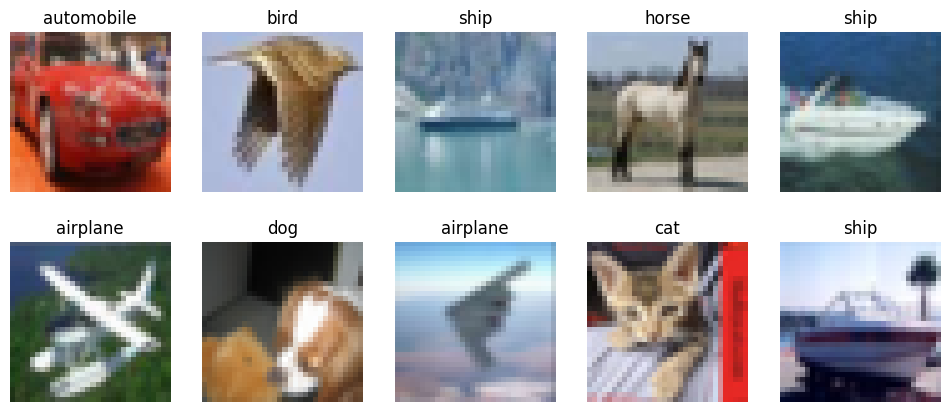

In [ ]:
# ==================================================
# VISUALIZAR EJEMPLOS DEL DATASET CON SUS ETIQUETAS
# ==================================================

# Visualizar 10 imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Lista manual de índices (aleatorios para mostrar variedad de las 10 clases)
random_list = [5, 123, 456, 789, 1011, 2345, 3456, 4567, 5678, 6789]

for i in range(0, 10):
    idx = random_list[i]
    axes[i].imshow(x_train_tl[idx] / 255.0)  # Normalizamos para mostrar correctamente
    axes[i].set_title(class_names[y_train_tl[idx]])
    axes[i].axis('off')

plt.show()

## ⚙️ NORMALIZACIÓN (PREPROCESAMIENTO)

---

In [ ]:
# =========================================================================
# PREPROCESAMIENTO DE IMAGENES Y CREACIÓN DE TF.DATA.DATASET
# =========================================================================

# Asumimos que x_train_tl, y_train_tl, x_test_tl, y_test_tl y class_names
# ya han sido cargados como arrays de NumPy en la celda anterior.

## 1. Definir el tamaño de imagen para MobileNetV2.
# -----------------------------------------------------
IMG_SIZE = 128

## 2. Definir la función de preprocesamiento para tf.data.Dataset.
# -----------------------------------------------------
def preprocess_image(image, label):
    # Redimensiona la imagen al tamaño requerido.
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Convierte la imagen a float32.
    image = tf.cast(image, tf.float32)
    # Aplica el preprocesamiento específico de MobileNetV2 (normalización de píxeles).
    image = preprocess_input(image)
    return image, label

## 3. Configurar AUTOTUNE y BATCH_SIZE.
# -----------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

## 4. Convertir arrays de imágenes a tensores de TensorFlow.
# -----------------------------------------------------
x_train_tl = tf.cast(x_train_tl, tf.float32)
x_test_tl = tf.cast(x_test_tl, tf.float32)

## 5. Crear y configurar el tf.data.Dataset de TRAIN.
# -----------------------------------------------------
train_ds = tf.data.Dataset.from_tensor_slices((x_train_tl, y_train_tl))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
# Se ha eliminado el '.cache()' para reducir el consumo de RAM. ← CLAVE
train_ds = train_ds.shuffle(buffer_size=1024)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

## 6. Crear y configurar el tf.data.Dataset de TEST.
# -----------------------------------------------------
test_ds = tf.data.Dataset.from_tensor_slices((x_test_tl, y_test_tl))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
# Se ha eliminado el '.cache()' para reducir el consumo de RAM. ← CLAVE
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## 7. Imprimir la configuración final de los datasets y el tamaño de las imágenes.
# -----------------------------------------------------
print(f'Train Dataset: {train_ds}')
print(f'Test Dataset: {test_ds}')
print(f'Image shape (TL): ({IMG_SIZE}, {IMG_SIZE}, 3)')

Train Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Test Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Image shape (TL): (128, 128, 3)


## 🏠 ARQUITECTURA (CONSTRUCCIÓN)

---


In [ ]:
# ========================
# CONSTRUCCIÓN DEL MODELO
# ========================

## 1. Cargar MobileNetV2 preentrenado como modelo base.
# -----------------------------------------------------
# Carga MobileNetV2 preentrenado en ImageNet sin las capas clasificadoras finales.
# Input shape ajustado a (128, 128, 3).
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

## 2. Congelar todas las capas del modelo base.
# -----------------------------------------------------
# Congela el modelo base para Feature Extraction, sus pesos no se actualizarán.
base_model.trainable = False

## 3. Construir el modelo secuencial (cabeza clasificadora).
# -----------------------------------------------------
# Crea un modelo Sequential y añade el MobileNetV2 congelado.
model = Sequential()
model.add(Input(shape=(128, 128, 3))) # Capa de entrada.
model.add(base_model)                 # Añade el modelo base.

## 4. Añadir capas Global Average Pooling y Dense para clasificación.
# -----------------------------------------------------
# Reduce dimensiones espaciales y prepara la salida para capas densas.
model.add(GlobalAveragePooling2D())

# Capa Densa con activación 'relu'.
model.add(Dense(64, activation='relu'))

# Dropout para reducir el sobreajuste (40%).
model.add(Dropout(0.40))

# Capa de salida con 10 neuronas (una por clase), activación 'softmax'.
model.add(Dense(10, activation='softmax'))

## 5. Mostrar resumen del modelo.
# -----------------------------------------------------
# Imprime la arquitectura del modelo y parámetros entrenables/no entrenables.
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 🏋️‍♂️ COMPILAR Y ENTRENAR

---


In [ ]:
# ============================
# COMPILACIÓN Y ENTRENAMIENTO
# ============================

## 1. Compilar el modelo (etapa 1: solo cabeza - Feature Extraction)
# -----------------------------------------------------------------
# Configura optimizador (SGD con LR bajo y momentum), pérdida (sparse_categorical_crossentropy)
# y métricas (accuracy).
model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2. Configurar Early Stopping
# -----------------------------------------------------
# Define Early Stopping para detener si 'val_loss' no mejora en 5 épocas.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

## 3. Entrenar el modelo (etapa 1: solo cabeza - base congelada)
# -----------------------------------------------------------------
# Entrena el modelo con 'train_ds' y 'test_ds' para validación.
history = model.fit(
    train_ds,
    epochs=100,
    verbose=1,
    validation_data=test_ds,
    callbacks=[early_stop]
)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 29ms/step - accuracy: 0.5908 - loss: 1.2095 - val_accuracy: 0.8192 - val_loss: 0.5173
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7909 - loss: 0.6203 - val_accuracy: 0.8346 - val_loss: 0.4725
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.8121 - loss: 0.5592 - val_accuracy: 0.8422 - val_loss: 0.4481
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.8238 - loss: 0.5181 - val_accuracy: 0.8457 - val_loss: 0.4388
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8310 - loss: 0.4952 - val_accuracy: 0.8497 - val_loss: 0.4302
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.8389 - loss: 0.4750 - val_accuracy: 0.8520 - val_loss: 0.4237
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.8436 - loss: 0.4627 - val_accuracy: 0.8521 - val_loss: 0.4156
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 

## 🔮 PREDECIR Y EVALUAR (MATRIZ DE CONFUSIÓN)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.89      0.87      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.88      0.80      0.84      1000
         cat       0.74      0.76      0.75      1000
        deer       0.82      0.83      0.82      1000
         dog       0.82      0.81      0.81      1000
        frog       0.88      0.90      0.89      1000
       horse       0.87      0.88      0.88      1000
        ship       0.91      0.91      0.91      1000
       truck       0.93      0.90      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



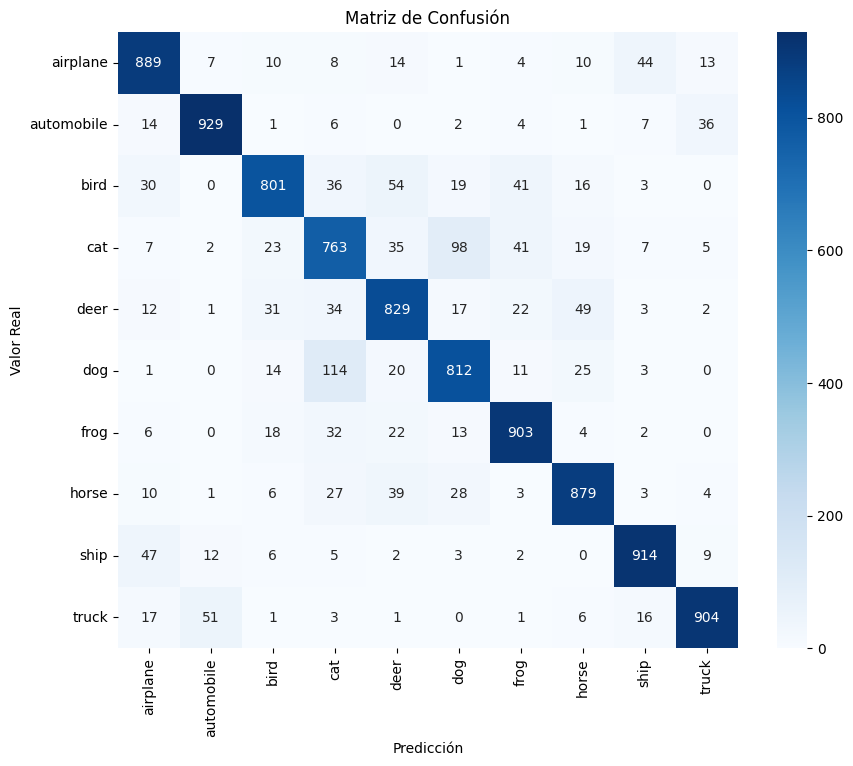

In [ ]:
# ===============================================
# PREDICCIONES Y EVALUACIÓN (MATRIZ DE CONFUSIÓN)
# ===============================================

## 1. Preprocesar las imágenes de prueba.
# -----------------------------------------------------
# Redimensionar y aplicar el preprocesamiento específico de MobileNetV2
# a las imágenes de prueba para que coincidan con la entrada del modelo.
x_test_preprocessed = tf.image.resize(x_test_tl, (IMG_SIZE, IMG_SIZE))
x_test_preprocessed = preprocess_input(x_test_preprocessed)

## 2. Realizar predicciones en el conjunto de prueba.
# -----------------------------------------------------
# Obtener las probabilidades de predicción para cada clase en el conjunto de prueba.
y_pred_probs = model.predict(x_test_preprocessed, verbose=0)

## 3. Convertir probabilidades a etiquetas predichas.
# -----------------------------------------------------
# Para clasificación multiclase, se selecciona la clase con la probabilidad más alta.
y_pred = np.argmax(y_pred_probs, axis=1)

## 4. Generar y mostrar el Classification Report.
# -----------------------------------------------------
# Evaluar el rendimiento del modelo mostrando métricas como precisión, recall y f1-score.
report = classification_report(y_test_tl, y_pred, target_names=class_names)
print('Classification Report:')
print(report)

## 5. Generar y mostrar la "Matriz de Confusión".
# -----------------------------------------------------
# Calcular la matriz de confusión para visualizar las predicciones correctas e incorrectas por clase.
cm = confusion_matrix(y_test_tl, y_pred)

# Visualizar la matriz de confusión usando un mapa de calor (heatmap).
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

## 📈 VISUALIZAR CURVAS DE APRENDIZAJE

---

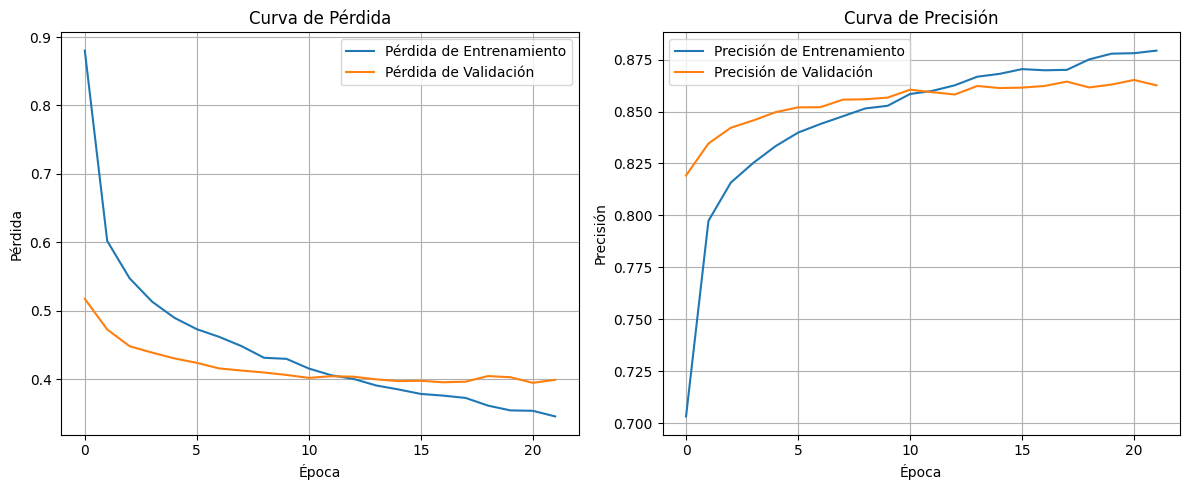

TRAIN:
Loss óptimo: 0.3536
Accuracy óptimo: 87.81%
Loss final: 0.3454
Accuracy final: 87.93%

VALIDATION:
Loss óptimo: 0.3946
Accuracy óptimo: 86.52%
Loss final: 0.3989
Accuracy final: 86.26%


In [ ]:
# ===============================================
# VISUALIZAR CURVAS DE APRENDIZAJE
# ===============================================

## 1. Obtener los datos del historial de entrenamiento.
# -----------------------------------------------------
# Convierte el objeto history a un DataFrame de Pandas para fácil manejo.
hist_df = pd.DataFrame(history.history)

## 2. Configurar la figura para las gráficas de pérdida y precisión.
# -----------------------------------------------------
plt.figure(figsize=(12, 5))

## 3. Gráfico de la pérdida (Loss).
# -----------------------------------------------------
plt.subplot(1, 2, 1) # Define el primer subplot (1 fila, 2 columnas, posición 1).
plt.plot(hist_df['loss'], label='Pérdida de Entrenamiento')
plt.plot(hist_df['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

## 4. Gráfico de la precisión (Accuracy).
# -----------------------------------------------------
plt.subplot(1, 2, 2) # Define el segundo subplot (1 fila, 2 columnas, posición 2).
plt.plot(hist_df['accuracy'], label='Precisión de Entrenamiento')
plt.plot(hist_df['val_accuracy'], label='Precisión de Validación')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

## 5. Ajustar el diseño y mostrar las gráficas.
# -----------------------------------------------------
plt.tight_layout()
plt.show()

## 6. Mostrar valores de entrenamiento y validación.
# -----------------------------------------------------
# Encuentra la época con la menor pérdida de validación.
best_epoch = np.argmin(history.history['val_loss'])

print(f"TRAIN:")
print(f"Loss óptimo: {history.history['loss'][best_epoch]:.4f}")
print(f"Accuracy óptimo: {history.history['accuracy'][best_epoch]*100:.2f}%")
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['accuracy'][-1]*100:.2f}%")
print()
print(f"VALIDATION:")
print(f"Loss óptimo: {history.history['val_loss'][best_epoch]:.4f}")
print(f"Accuracy óptimo: {history.history['val_accuracy'][best_epoch]*100:.2f}%")
print(f"Loss final: {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['val_accuracy'][-1]*100:.2f}%")

# **# FINE TUNING (BONUS)**

## **¿? CONCLUSIONES**
---
*  Mejora del Rendimiento: La precisión general del modelo en el conjunto de validación mejoró del ~86% al ~94%.
*   Fine-Tuning nos ha permitido que el modelo se adaptara eficazmente a las características específicas del dataset CIFAR-10, especialmente mejorando el rendimiento en clases inicialmente más difíciles como 'cat' y 'dog'.
*   Las métricas de validación cercanas a las de entrenamiento indican una buena generalización y un overfiting efimero post-Fine-Tuning (<5%).

## 🖌️ PREPARACIÓN (Fine Tuning)

---

In [ ]:
# ========================================
# FINE-TUNING - DESCONGELAR ÚLTIMAS CAPAS
# ========================================

## 1. Asegurarse de que el modelo base sea entrenable.
# -----------------------------------------------------
# Establece el modelo base como entrenable para poder modificar sus pesos.
base_model.trainable = True

## 2. Descongelar las últimas 20 capas del modelo base.
# -----------------------------------------------------
# Permite que las últimas 20 capas del modelo preentrenado se ajusten durante el fine-tuning.
for layer in base_model.layers[-20:]:
    layer.trainable = True

## 3. Congelar todas las capas BatchNormalization.
# -----------------------------------------------------
# Esto se hace para evitar la inestabilidad que pueden causar las capas BatchNormalization
# con batches pequeños durante el fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

## 4. Contar capas entrenables y congeladas.
# -----------------------------------------------------
# Recorre las capas del modelo base para contar cuántas son entrenables y cuántas están congeladas.
trainable = 0
frozen = 0
for layer in base_model.layers:
    if layer.trainable:
        trainable += 1
    else:
        frozen += 1

## 5. Mostrar resumen del modelo y conteo de capas.
# -----------------------------------------------------
# Imprime la arquitectura del modelo con el estado de entrenabilidad de las capas.
model.summary()
print("Modelo Base - MobileNetV2:")
print(f"Capas entrenables: {trainable}")
print(f"Capas congeladas: {frozen}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,254 (9.24 MB)

 Trainable params: 2,272,394 (8.67 MB)

 Non-trainable params: 68,224 (266.50 KB)

 Optimizer params: 82,636 (322.80 KB)

Modelo Base - MobileNetV2:
Capas entrenables: 102
Capas congeladas: 52


## 🏋️‍♂️ RE-COMPILAR Y ENTRENAR (Fine-Tuning)

In [ ]:
# ===============================================
# RE-COMPILACIÓN Y ENTRENAMIENTO (FINE-TUNING)
# ===============================================

## 1. Re-compilar el modelo (después de descongelar capas para Fine-Tuning).
# -----------------------------------------------------------------
# Es CRÍTICO re-compilar el modelo después de modificar las capas entrenables.
# Se usa un optimizador Adam con una tasa de aprendizaje muy baja para el fine-tuning.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # Usar una LR muy baja para fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2. Configurar Early Stopping para Fine-Tuning.
# -----------------------------------------------------
# Configurar Early Stopping (puede que necesites más paciencia para fine-tuning).
early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=10, # Aumentar la paciencia para fine-tuning
    min_delta=0.0001,
    restore_best_weights=True,
    verbose=1
)

## 3. Entrenar el modelo (etapa: fine-tuning de algunas capas de la base y la cabeza).
# -----------------------------------------------------------------
# Entrenar el modelo con los datasets de TensorFlow y el nuevo Early Stopping.
history_ft = model.fit(
    train_ds,
    epochs=100, # Puedes aumentar las épocas
    verbose=1,
    validation_data=test_ds,
    callbacks=[early_stop_ft]
)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 54ms/step - accuracy: 0.8809 - loss: 0.3607 - val_accuracy: 0.9129 - val_loss: 0.2592
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.9173 - loss: 0.2527 - val_accuracy: 0.9188 - val_loss: 0.2421
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9364 - loss: 0.1946 - val_accuracy: 0.9284 - val_loss: 0.2231
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.9483 - loss: 0.1516 - val_accuracy: 0.9342 - val_loss: 0.2120
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.9565 - loss: 0.1281 - val_accuracy: 0.9346 - val_loss: 0.2167
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.9650 - loss: 0.1042 - val_accuracy: 0.9396 - val_loss: 0.2177
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.9739 - loss: 0.0779 - val_accuracy: 0.9403 - val_loss: 0.2112
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy:

## 🔮 PREDECIR Y EVALUAR (Fine Tuning)

---

Classification Report (Fine-Tuning):
              precision    recall  f1-score   support

    airplane       0.95      0.93      0.94      1000
  automobile       0.95      0.98      0.96      1000
        bird       0.94      0.94      0.94      1000
         cat       0.85      0.92      0.88      1000
        deer       0.93      0.94      0.93      1000
         dog       0.93      0.89      0.91      1000
        frog       0.98      0.95      0.96      1000
       horse       0.96      0.93      0.94      1000
        ship       0.95      0.97      0.96      1000
       truck       0.98      0.95      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



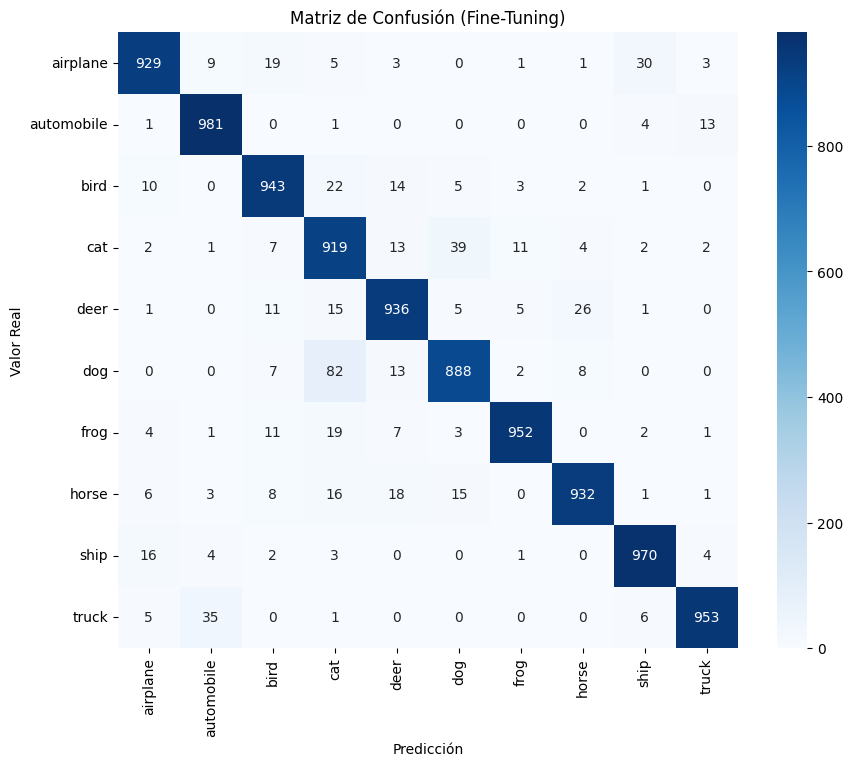

In [ ]:
# =================================================
# PREDICCIONES Y EVALUACIÓN DESPUÉS DE FINE-TUNING
# =================================================

## 1. Preprocesar las imágenes de prueba.
# -----------------------------------------------------
# Asegurarse de que x_test_tl esté preprocesado al tamaño correcto
# (IMG_SIZE y preprocess_input son variables globales definidas previamente).
x_test_preprocessed = tf.image.resize(x_test_tl, (IMG_SIZE, IMG_SIZE))
x_test_preprocessed = preprocess_input(x_test_preprocessed)

## 2. Realizar predicciones en el conjunto de prueba.
# -----------------------------------------------------
# Obtener las probabilidades de predicción para cada clase.
y_pred_probs_ft = model.predict(x_test_preprocessed, verbose=0)

## 3. Convertir probabilidades a etiquetas predichas.
# -----------------------------------------------------
# Para clasificación multiclase, se selecciona la clase con la probabilidad más alta.
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

## 4. Generar y mostrar el Classification Report.
# -----------------------------------------------------
# Evaluar el rendimiento del modelo con métricas como precisión, recall y f1-score.
report_ft = classification_report(y_test_tl, y_pred_ft, target_names=class_names)
print('Classification Report (Fine-Tuning):')
print(report_ft)

## 5. Generar y mostrar la Matriz de Confusión.
# -----------------------------------------------------
# Calcular la matriz de confusión para visualizar las predicciones correctas e incorrectas.
cm_ft = confusion_matrix(y_test_tl, y_pred_ft)

# Visualizar la matriz de confusión usando un mapa de calor.
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Fine-Tuning)')
plt.show()

## 📈 VISUALIZAR CURVAS DE APRENDIZAJE (Fine Tuning)

---

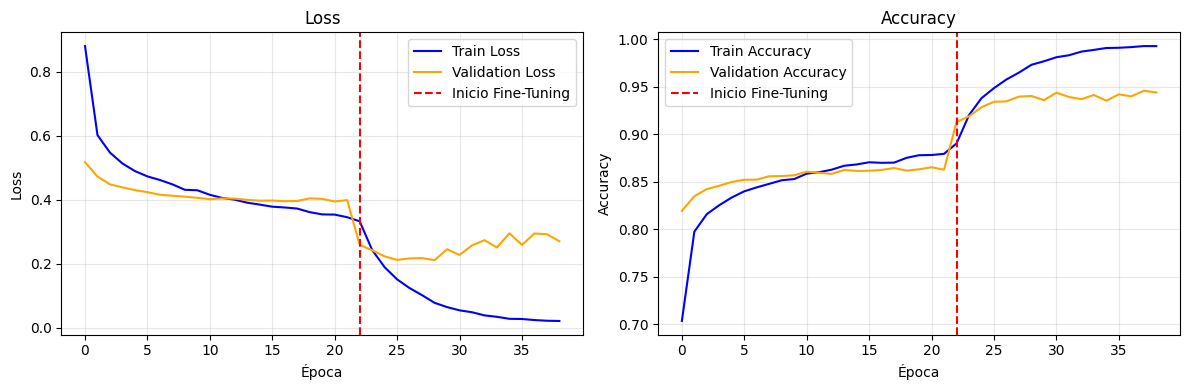

TRAIN (Fine-Tuning):
Loss óptimo: 0.0779
Accuracy óptimo: 97.31%
Loss final: 0.0212
Accuracy final: 99.28%

VALIDATION (Fine-Tuning):
Loss óptimo: 0.2112
Accuracy óptimo: 94.03%
Loss final: 0.2703
Accuracy final: 94.40%


In [ ]:
# ===============================================
# VISUALIZAR CURVAS DE APRENDIZAJE (Fine Tuning)
# ===============================================

## 1. Obtener los datos del historial de entrenamiento (combinando Feature Extraction y Fine-Tuning).
# -----------------------------------------------------
# Combina los historiales de accuracy, val_accuracy, loss y val_loss de ambas fases.
acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss = history.history['loss'] + history_ft.history['loss']
val_loss = history.history['val_loss'] + history_ft.history['val_loss']

## 2. Calcular el punto de inicio del Fine-Tuning.
# -----------------------------------------------------
# Determina la época en la que comenzó la fase de Fine-Tuning.
initial_epochs = len(history.history['loss'])

## 3. Configurar la figura para las gráficas de pérdida y precisión.
# -----------------------------------------------------
# Crea una figura con dos subgráficos para pérdida y precisión.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

## 4. Gráfico de la pérdida (Loss).
# -----------------------------------------------------
# Muestra la pérdida de entrenamiento y validación a lo largo de las épocas.
axes[0].plot(loss, label='Train Loss', color='blue')
axes[0].plot(val_loss, label='Validation Loss', color='orange')
axes[0].axvline(x=initial_epochs, color='red', linestyle='--', label='Inicio Fine-Tuning')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

## 5. Gráfico de la precisión (Accuracy).
# -----------------------------------------------------
# Muestra la precisión de entrenamiento y validación a lo largo de las épocas.
axes[1].plot(acc, label='Train Accuracy', color='blue')
axes[1].plot(val_acc, label='Validation Accuracy', color='orange')
axes[1].axvline(x=initial_epochs, color='red', linestyle='--', label='Inicio Fine-Tuning')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

## 6. Ajustar el diseño y mostrar las gráficas.
# -----------------------------------------------------
plt.tight_layout()
plt.show()

## 7. Mostrar valores finales y óptimos de entrenamiento y validación (DESPUÉS DEL FINE-TUNING).
# -----------------------------------------------------
# Encuentra la época con la menor pérdida de validación durante el fine-tuning.
best_epoch_ft = np.argmin(history_ft.history['val_loss'])

print(f"TRAIN (Fine-Tuning):")
print(f"Loss óptimo: {history_ft.history['loss'][best_epoch_ft]:.4f}")
print(f"Accuracy óptimo: {history_ft.history['accuracy'][best_epoch_ft]*100:.2f}%")
print(f"Loss final: {history_ft.history['loss'][-1]:.4f}")
print(f"Accuracy final: {history_ft.history['accuracy'][-1]*100:.2f}%")
print()
print(f"VALIDATION (Fine-Tuning):")
print(f"Loss óptimo: {history_ft.history['val_loss'][best_epoch_ft]:.4f}")
print(f"Accuracy óptimo: {history_ft.history['val_accuracy'][best_epoch_ft]*100:.2f}%")
print(f"Loss final: {history_ft.history['val_loss'][-1]:.4f}")
print(f"Accuracy final: {history_ft.history['val_accuracy'][-1]*100:.2f}%")

## 🖼️ VISUALIZAR PREDICCIONES (Fine Tuning)

---

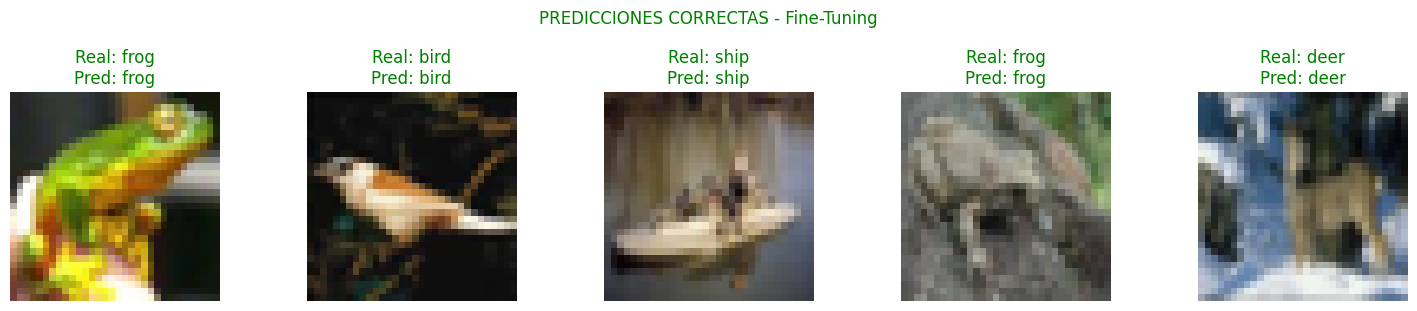

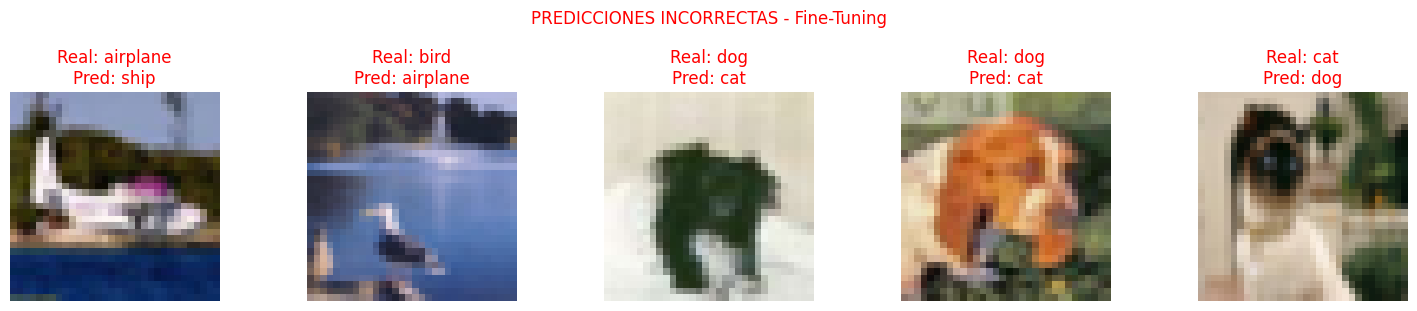

In [ ]:
# ===============================================
# VISUALIZAR PREDICCIONES DEL MODELO (FINE-TUNING)
# Se muestran 5 correctas y 5 incorrectas (ordenadas por fila)
# ===============================================

## 1. Preprocesar las imágenes de prueba.
# -----------------------------------------------------
# Asegurarse de que x_test_tl esté preprocesado al tamaño correcto para la predicción.
x_test_preprocessed_full = tf.image.resize(tf.cast(x_test_tl, tf.float32), (IMG_SIZE, IMG_SIZE))
x_test_preprocessed_full = preprocess_input(x_test_preprocessed_full)

## 2. Realizar predicciones en todo el conjunto de prueba.
# -----------------------------------------------------
# Obtener las probabilidades de predicción para cada clase en el conjunto de prueba.
y_pred_probs_full = model.predict(x_test_preprocessed_full, verbose=0)
# Convertir probabilidades a etiquetas predichas (la clase con mayor probabilidad).
y_pred_full = np.argmax(y_pred_probs_full, axis=1)

## 3. Identificar índices de predicciones correctas e incorrectas.
# -----------------------------------------------------
correct_indices = np.where(y_pred_full == y_test_tl)[0]
incorrect_indices = np.where(y_pred_full != y_test_tl)[0]

## 4. Seleccionar aleatoriamente índices para visualización.
# -----------------------------------------------------
# Se seleccionan 5 ejemplos de predicciones correctas e incorrectas (si hay suficientes).
num_to_show = 5
selected_correct_indices = np.random.choice(correct_indices, min(num_to_show, len(correct_indices)), replace=False)
selected_incorrect_indices = np.random.choice(incorrect_indices, min(num_to_show, len(incorrect_indices)), replace=False)

## 5. Visualizar predicciones correctas.
# -----------------------------------------------------
fig, axes = plt.subplots(1, num_to_show, figsize=(15, 3))
axes = axes.flatten()
for i, idx in enumerate(selected_correct_indices):
    # Mostrar la imagen original con sus etiquetas real y predicha.
    img = x_test_tl[idx]
    true_label = class_names[y_test_tl[idx]]
    predicted_label = class_names[y_pred_full[idx]]
    axes[i].imshow(img.numpy().astype('uint8'))
    axes[i].set_title(f"Real: {true_label}\nPred: {predicted_label}", color="green")
    axes[i].axis('off')
plt.suptitle('PREDICCIONES CORRECTAS - Fine-Tuning', color='green', y=1.02)
plt.tight_layout()
plt.show()

## 6. Visualizar predicciones incorrectas.
# -----------------------------------------------------
fig, axes = plt.subplots(1, num_to_show, figsize=(15, 3))
axes = axes.flatten()
for i, idx in enumerate(selected_incorrect_indices):
    # Mostrar la imagen original con sus etiquetas real y predicha.
    img = x_test_tl[idx]
    true_label = class_names[y_test_tl[idx]]
    predicted_label = class_names[y_pred_full[idx]]
    axes[i].imshow(img.numpy().astype('uint8'))
    axes[i].set_title(f"Real: {true_label}\nPred: {predicted_label}", color="red")
    axes[i].axis('off')
plt.suptitle('PREDICCIONES INCORRECTAS - Fine-Tuning', color='red', y=1.02)
plt.tight_layout()
plt.show()